# Module 00 — The Estimator Contract

**The single most useful thing to know about scikit-learn is that it is not
a collection of algorithms. It is one interface, implemented ~200 times.**

Almost everyone who "knows sklearn from notebooks" knows a handful of
algorithms and stitches them together by copying cells. Everyone who is
genuinely fluent knows the *contract* — and can therefore use an estimator
they have never seen before, correctly, on the first try, from the docstring
alone.

This module is about the contract.

---

### Learning objectives

By the end you will be able to:

1. State the four verbs (`fit`, `transform`, `predict`, `score`) and the rules
   about which objects have which.
2. Explain the trailing-underscore convention and why it is load-bearing, not
   cosmetic.
3. Distinguish a *hyperparameter* (set in `__init__`, visible to
   `get_params`) from a *learned parameter* (set in `fit`, trailing
   underscore) — and explain why that distinction is what makes
   `GridSearchCV` possible at all.
4. Read any scikit-learn docstring and predict the object's behaviour.
5. Navigate the library's namespace by *task* rather than by memory.

### How to work through this

Run every cell. Then, before you read the output of a cell, guess it. The
guessing is the learning; the running only confirms it.

In [13]:
# --- Standard preamble used by every notebook in this curriculum -----------
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import sklearn

from skmastery import set_plot_style

set_plot_style()
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)

print(f"scikit-learn {sklearn.__version__}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")

scikit-learn 1.9.0
numpy        2.5.3
pandas       3.0.5


## 1. The four verbs

Every object in scikit-learn is one of four kinds, defined entirely by which
methods it has:

| Kind | Has | Example | What it is for |
|---|---|---|---|
| **Estimator** | `fit(X, y=None)` | everything | learns something from data |
| **Transformer** | `+ transform(X)` | `StandardScaler` | changes the feature matrix |
| **Predictor** | `+ predict(X)` | `LogisticRegression` | produces an output per row |
| **Model** | `+ score(X, y)` | most predictors | reports a default quality number |

These compose. `PCA` is an estimator *and* a transformer.
`LogisticRegression` is an estimator, a predictor and a model — but not a
transformer. `KMeans` is unusual: it is all four (it can transform `X` into
distances-to-centroids).

That is the whole taxonomy. There is no fifth thing.

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

VERBS = ["fit", "transform", "fit_transform", "predict", "predict_proba", "score", "inverse_transform"]

survey = pd.DataFrame(
    {
        obj.__class__.__name__: [hasattr(obj, v) for v in VERBS]
        for obj in [StandardScaler(), PCA(), LogisticRegression(), KMeans(n_init="auto")]
    },
    index=VERBS,
)
survey

,StandardScaler,PCA,LogisticRegression,KMeans
fit,True,True,True,True
transform,True,True,False,True
fit_transform,True,True,False,True
predict,False,False,True,True
predict_proba,False,False,True,False
score,False,True,True,True
inverse_transform,True,True,False,False


**Read that table carefully.** It answers questions people usually resolve by
trial and error:

- Why can't you put `LogisticRegression` in the middle of a `Pipeline`?
  Because it has no `transform`. A pipeline is *n* transformers followed by at
  most one predictor.
- Why does `StandardScaler` have `inverse_transform` but `PCA`'s is lossy?
  Because scaling is a bijection and projection is not.
- Why does `KMeans` have both `predict` and `transform`? Because "which
  cluster" and "how far from each centroid" are both useful outputs.

## 2. The trailing underscore is a promise

scikit-learn splits an object's state into two disjoint sets:

- **Hyperparameters** — passed to `__init__`, stored *unmodified* on `self`
  under the same name, no underscore. `alpha`, `n_estimators`, `C`.
- **Learned parameters** — computed in `fit`, stored with a **trailing
  underscore**. `coef_`, `mean_`, `classes_`, `n_features_in_`.

The rule is enforced by the library's own test suite and it is not decoration.
Three things depend on it:

1. `get_params()` / `set_params()` can enumerate everything tunable, which is
   what lets `GridSearchCV` exist without knowing anything about the estimator.
2. `clone(est)` can produce an unfitted twin by copying only the
   hyperparameters — which is what lets cross-validation avoid leaking a fit
   from one fold into the next.
3. `check_is_fitted(est)` can tell fitted from unfitted by looking for *any*
   trailing-underscore attribute.

The corollary, which trips people up: **`__init__` must not validate or
transform its arguments.** `StandardScaler(with_mean="yes")` will not complain
until you call `fit`. That feels wrong until you realise `clone` depends on
`init` being a pure assignment.

In [3]:
from sklearn.base import clone
from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted

scaler = StandardScaler()

print("Hyperparameters (before fit):", scaler.get_params())
print("Trailing-underscore attrs   :", [a for a in vars(scaler) if a.endswith("_")])

try:
    check_is_fitted(scaler)
except NotFittedError as e:
    print("\ncheck_is_fitted ->", type(e).__name__)

X_demo = np.array([[1.0, 10.0], [2.0, 20.0], [3.0, 30.0], [4.0, 45.0]])
scaler.fit(X_demo)

print("\nAfter fit:", {a: np.round(v, 3) for a, v in vars(scaler).items() if a.endswith("_")})
check_is_fitted(scaler)
print("check_is_fitted -> passes")

Hyperparameters (before fit): {'copy': True, 'with_mean': True, 'with_std': True}
Trailing-underscore attrs   : []

check_is_fitted -> NotFittedError

After fit: {'n_features_in_': np.int64(2), 'n_samples_seen_': np.float64(4.0), 'mean_': array([ 2.5 , 26.25]), 'var_': array([  1.25 , 167.188]), 'scale_': array([ 1.118, 12.93 ])}
check_is_fitted -> passes


In [4]:
# clone() copies hyperparameters ONLY. This is the mechanism that makes
# cross-validation honest: each fold gets a virgin estimator.
twin = clone(scaler)
print("twin params identical:", twin.get_params() == scaler.get_params())
print("twin is fitted       :", any(a.endswith("_") for a in vars(twin)))
print("twin is same object  :", twin is scaler)

twin params identical: True
twin is fitted       : False
twin is same object  : False


### Why this matters more than it looks

A very common bug in hand-rolled ML code:

```python
model = LogisticRegression()
for train_idx, test_idx in folds:
    model.fit(X[train_idx], y[train_idx])   # same object, refitted
    ...
```

With sklearn estimators this happens to be fine, because `fit` resets state.
With a stateful custom estimator, or with `warm_start=True`, it silently is
not. `cross_val_score` calls `clone` for exactly this reason — it never
trusts `fit` to reset.

## 3. `fit` / `transform` / `predict`: who is allowed to see what

This is the rule that prevents most data leakage:

> **`fit` may look at the training data. `transform` and `predict` may only
> look at the row in front of them plus the learned parameters.**

`StandardScaler.fit` computes `mean_` and `scale_` from the training set.
`transform` then applies those *same numbers* to any data, including the test
set. If you instead called `fit_transform` on the test set, the test set's own
mean would leak into its representation and your estimate of generalisation
would be optimistic.

Below, the same idea shown numerically.

In [5]:
rng = np.random.default_rng(0)
X_train = rng.normal(loc=50, scale=10, size=(200, 1))
X_test = rng.normal(loc=58, scale=14, size=(50, 1))  # test set has drifted

sc = StandardScaler().fit(X_train)

correct = sc.transform(X_test)          # train statistics applied to test
wrong = StandardScaler().fit_transform(X_test)  # test statistics -- leakage

print(f"train mean/scale learned : {sc.mean_[0]:.2f} / {sc.scale_[0]:.2f}")
print(f"correct  -> test mean {correct.mean():+.3f}  std {correct.std():.3f}   (drift is visible)")
print(f"wrong    -> test mean {wrong.mean():+.3f}  std {wrong.std():.3f}   (drift erased)")

train mean/scale learned : 50.15 / 9.61
correct  -> test mean +0.684  std 1.765   (drift is visible)
wrong    -> test mean -0.000  std 1.000   (drift erased)


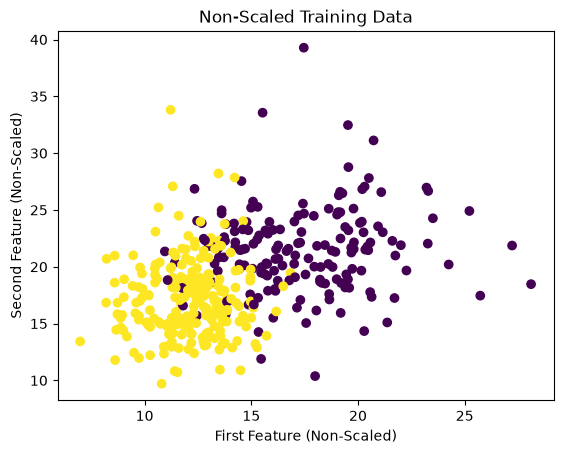

train mean/scale learned : [1.43212225e+01 1.89528750e+01 9.33214500e+01 6.73218000e+02
 9.69333250e-02 1.06833500e-01 9.41457418e-02 5.18568175e-02
 1.83199750e-01 6.27828000e-02 4.21032500e-01 1.19611000e+00
 2.96857050e+00 4.22796700e+01 7.01028500e-03 2.62360650e-02
 3.30521815e-02 1.20786050e-02 2.11653700e-02 3.87241325e-03
 1.65978375e+01 2.53252250e+01 1.09434925e+02 9.17176750e+02
 1.33196275e-01 2.62463400e-01 2.83429543e-01 1.19292953e-01
 2.96377250e-01 8.44873750e-02] / [3.57378915e+00 4.11675758e+00 2.46195812e+01 3.56828591e+02
 1.39072703e-02 5.48451346e-02 8.20544491e-02 3.99146544e-02
 2.84189466e-02 7.21859776e-03 2.77288250e-01 5.37680602e-01
 2.04036176e+00 4.35650154e+01 3.06521337e-03 1.91639231e-02
 3.33491925e-02 6.44382048e-03 9.05008988e-03 2.88512652e-03
 4.95765203e+00 6.11217768e+00 3.43558884e+01 5.82468239e+02
 2.33976397e-02 1.66010163e-01 2.13323635e-01 6.77399397e-02
 6.69348759e-02 1.89884459e-02]
train scaled mean/std    : [-4.29684066e-15 -1.530442

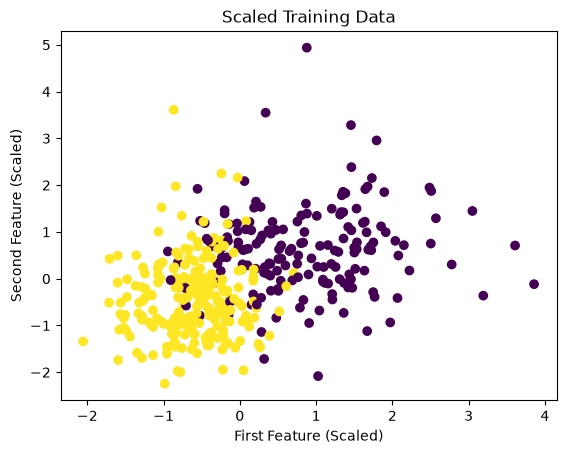

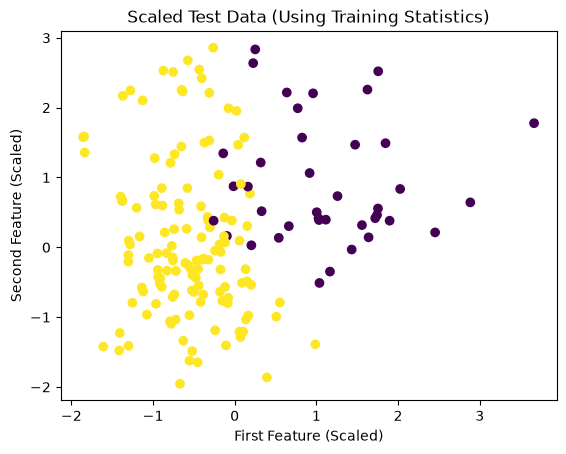

In [8]:
# load breast cance dataset and scale it, then fit a logistic regression to it in a pipeline
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test = X.iloc[:400], X.iloc[400:]
y_train, y_test = y.iloc[:400], y.iloc[400:]
# plot non-scaled training data for comparison
X_train_non_scaled = X_train.values
plt.scatter(X_train_non_scaled[:, 0], X_train_non_scaled[:, 1], c=y_train, cmap='viridis')
plt.xlabel('First Feature (Non-Scaled)')
plt.ylabel('Second Feature (Non-Scaled)')
plt.title('Non-Scaled Training Data')
plt.show()
sc = StandardScaler().fit(X_train)
X_train_scaled = sc.transform(X_train)
print(f"train mean/scale learned : {sc.mean_} / {sc.scale_}")
print(f"train scaled mean/std    : {X_train_scaled.mean(axis=0)} / {X_train_scaled.std(axis=0)}")
print(f"test  mean/std            : {X_test.mean(axis=0)} / {X_test.std(axis=0)}")
# display plot of the first two features of the scaled training data
import matplotlib.pyplot as plt

plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='viridis')
plt.xlabel('First Feature (Scaled)')
plt.ylabel('Second Feature (Scaled)')
plt.title('Scaled Training Data')
plt.show()
#plot test data scaled with training statistics
X_test_scaled = sc.transform(X_test)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, cmap='viridis')
plt.xlabel('First Feature (Scaled)')
plt.ylabel('Second Feature (Scaled)')      
plt.title('Scaled Test Data (Using Training Statistics)')
plt.show()

The "wrong" version produces a beautifully standardised test set — mean 0,
std 1 — and in doing so **destroys the very evidence** that the population has
shifted. The model looks fine in your notebook and degrades in production.

> 💼 **Consulting lens.** When you review someone's modelling work, "did any
> `fit` ever touch data that stands in for the future?" catches more real
> defects than any question about model choice. Ask it first.

## 4. Hyperparameters are introspectable — that is the whole trick

`get_params(deep=True)` walks nested estimators and returns a flat dict keyed
with `__`. That flat namespace is what you type into a grid search. Learn to
*derive* those key names rather than guess them.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

demo_pipe = Pipeline(
    [
        (
            "prep",
            ColumnTransformer(
                [
                    ("num", Pipeline([("imp", SimpleImputer()), ("sc", StandardScaler())]), ["a", "b"]),
                    ("cat", OneHotEncoder(handle_unknown="ignore"), ["c"]),
                ]
            ),
        ),
        ("clf", LogisticRegression()),
    ]
)

keys = sorted(demo_pipe.get_params(deep=True))
print(f"{len(keys)} tunable keys. The ones you would actually search:\n")
for k in keys:
    if k.endswith(("__C", "__strategy", "__with_mean", "__min_frequency", "__penalty")):
        print(" ", k)

52 tunable keys. The ones you would actually search:

  clf
  clf__C
  clf__class_weight
  clf__dual
  clf__fit_intercept
  clf__intercept_scaling
  clf__l1_ratio
  clf__max_iter
  clf__n_jobs
  clf__penalty
  clf__random_state
  clf__solver
  clf__tol
  clf__verbose
  clf__warm_start
  memory
  prep
  prep__cat
  prep__cat__categories
  prep__cat__drop
  prep__cat__dtype
  prep__cat__feature_name_combiner
  prep__cat__handle_unknown
  prep__cat__max_categories
  prep__cat__min_frequency
  prep__cat__sparse_output
  prep__n_jobs
  prep__num
  prep__num__imp
  prep__num__imp__add_indicator
  prep__num__imp__copy
  prep__num__imp__fill_value
  prep__num__imp__keep_empty_features
  prep__num__imp__missing_values
  prep__num__imp__strategy
  prep__num__memory
  prep__num__sc
  prep__num__sc__copy
  prep__num__sc__with_mean
  prep__num__sc__with_std
  prep__num__steps
  prep__num__transform_input
  prep__num__verbose
  prep__remainder
  prep__sparse_threshold
  prep__transformer_weights
  p

Reading `prep__num__imp__strategy` right to left: the `strategy` of the step
named `imp`, inside the pipeline registered as `num`, inside the step named
`prep`. Every `__` is one level down. There is no magic and nothing to
memorise — you can always recover the name with `get_params`.

In [7]:
# Setting them works the same way, and returns self so it chains.
demo_pipe.set_params(clf__C=0.05, prep__num__imp__strategy="median")
print(demo_pipe.get_params()["clf__C"], demo_pipe.get_params()["prep__num__imp__strategy"])

0.05 median


## 5. The data contract: `X` and `y`

- `X` is 2-D: `(n_samples, n_features)`. Always. A single feature is
  `(n, 1)`, not `(n,)`. A single sample is `(1, n)`.
- `y` is 1-D `(n_samples,)` for single-output problems, 2-D for multi-output.
- **Rows are samples, columns are features.** Never the transpose. (This is the
  opposite of the convention in a lot of statistics and econometrics
  literature, which is why people coming from R trip on it.)

scikit-learn will accept numpy arrays, pandas DataFrames, scipy sparse
matrices, and — increasingly — anything implementing the Array API
(PyTorch tensors, CuPy arrays) for a growing subset of estimators.

In [20]:
one_feature = np.array([1.0, 2.0, 3.0, 4.0])
print("shape as given:", one_feature.shape)

try:
    StandardScaler().fit(one_feature)
except ValueError as e:
    print("\nsklearn says:\n ", str(e).split("\n")[0])

print("\nfixed (mean):", StandardScaler().fit(one_feature.reshape(-1, 1)).mean_)
print("\nfixed (scale):", StandardScaler().fit(one_feature.reshape(-1, 1)).scale_)
print ("\n Shape of one_feature after reshape:", one_feature.reshape(-1, 1).shape)
print ("\n one_feature after reshape:\n", one_feature.reshape(-1, 1))

# flattening back one-feature to 1D array after scaling
scaled_feature = one_feature.reshape(-1)#.transform(one_feature.reshape(-1, 1))
print("\nScaled feature (flattened back to 1D):", scaled_feature)
print('\n shape of scaled_feature after flattening:', scaled_feature.shape)

shape as given: (4,)

sklearn says:
  Expected 2D array, got 1D array instead:

fixed (mean): [2.5]

fixed (scale): [1.11803399]

 Shape of one_feature after reshape: (4, 1)

 one_feature after reshape:
 [[1.]
 [2.]
 [3.]
 [4.]]

Scaled feature (flattened back to 1D): [1. 2. 3. 4.]

 shape of scaled_feature after flattening: (4,)


### Feature names survive if you feed it a DataFrame

Since 1.0, estimators record `feature_names_in_` when fitted on a DataFrame,
and transformers implement `get_feature_names_out()`. This is the difference
between a model artefact you can audit and a wall of anonymous column indices.
**Always fit on a DataFrame when you have one.**

In [27]:
df_demo = pd.DataFrame({"income": [40_000, 55_000, 90_000], "age": [28, 41, 37]})
sc2 = StandardScaler().fit(df_demo)

print("feature_names_in_ :", sc2.feature_names_in_)
print("n_features_in_    :", sc2.n_features_in_)
print("\nfixed mean:", sc2.mean_)
print("\nfixed scale:", sc2.scale_)
print("\nfixed mean[income]:", sc2.mean_[0].round(2))
print("\nfixed scale[income]:", sc2.scale_[0].round(2))
print("\nfixed mean[age]:", sc2.mean_[1].round(2))
print("\nfixed scale[age]:", sc2.scale_[1].round(2))
print("get_feature_names_out():", sc2.get_feature_names_out())
print("n_features_in_    :", sc2.n_features_in_)

# scikit-learn *enforces* those names at transform time. Renaming a column is
# a hard error -- it means the caller is passing something other than what the
# estimator was fitted on.
try:
    sc2.transform(df_demo.rename(columns={"income": "salary"}))
except ValueError as e:
    print("\nRenamed column ->", str(e).split("\n")[0])

# Dropping the names entirely is only a warning: sklearn cannot tell whether
# you meant the same columns in the same order, so it lets it through noisily.
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    sc2.transform(df_demo.to_numpy())
    print("Bare numpy    ->", caught[0].category.__name__ if caught else "no warning")

feature_names_in_ : ['income' 'age']
n_features_in_    : 2

fixed mean: [6.16666667e+04 3.53333333e+01]

fixed scale: [2.09496751e+04 5.43650214e+00]

fixed mean[income]: 61666.67

fixed scale[income]: 20949.68

fixed mean[age]: 35.33

fixed scale[age]: 5.44
get_feature_names_out(): ['income' 'age']
n_features_in_    : 2

Renamed column -> The feature names should match those that were passed during fit.
Bare numpy    -> UserWarning


### `set_output` — keep DataFrames all the way through

By default transformers return numpy arrays, dropping column names. Since 1.2
you can ask for pandas (or, since 1.4, polars) output. For exploratory and
audit work this is worth switching on globally.

In [10]:
sc3 = StandardScaler().set_output(transform="pandas")
out = sc3.fit_transform(df_demo)
print(type(out).__name__)
out

DataFrame


,income,age
0,-1.034224,-1.348907
1,-0.318223,1.042337
2,1.352447,0.306570


In [11]:
# Globally, for a whole session:
from sklearn import set_config

set_config(transform_output="pandas")
print(type(StandardScaler().fit_transform(df_demo)).__name__)

set_config(transform_output="default")  # revert, so later modules show both

DataFrame


## 6. Everything at once: a first honest model

Here is the complete shape of a scikit-learn workflow. Nine lines. Read it as
the template that the next fourteen modules unpack.

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

model = Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))])
model.fit(X_tr, y_tr)

print(f"train accuracy {model.score(X_tr, y_tr):.3f}")
print(f"test  accuracy {model.score(X_te, y_te):.3f}")

train accuracy 0.991
test  accuracy 0.958


Four things in that cell are worth naming explicitly, because they recur:

1. **`stratify=y`** — keeps the class balance identical in both splits.
   Omit it on an imbalanced problem and your test set's base rate wanders.
2. **`random_state=0`** — reproducibility. Any sklearn object that makes a
   random choice takes this. Set it, always, and note it in your write-up.
3. **The `Pipeline`** — the scaler is fitted on `X_tr` only. Had you scaled
   before splitting, you would have leaked.
4. **`.score()`** — every model has a default metric (accuracy for
   classifiers, R² for regressors). It is a convenience, not a decision tool.
   Module 08 is about why.

In [ ]:
# one more practice model: fit a StandardScaler on a different dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
# Ridge regression is a linear model that includes L2 regularization, 
# which can help prevent overfitting by penalizing large coefficients. 
# In this example, we will create a pipeline that first scales the features using StandardScaler 
# and then fits a Ridge regression model to the scaled data.
model = Pipeline([("scale", StandardScaler()), ("reg", Ridge())])
model.fit(X_train, y_train)

print(f"train R² {model.score(X_train, y_train):.3f}")
print(f"test  R² {model.score(X_test, y_test):.3f}")

train R² 0.611
test  R² 0.591


## 7. Reading the library: navigate by task, not by memory

scikit-learn's namespace is organised by *what you are doing*, and knowing the
map beats knowing the names.

| Module | What lives there |
|---|---|
| `sklearn.datasets` | toy + fetchable datasets, `make_*` generators |
| `sklearn.preprocessing` | scalers, encoders, discretisers, transforms of X |
| `sklearn.impute` | missing-value strategies |
| `sklearn.feature_extraction` | raw text/dict → features |
| `sklearn.feature_selection` | reducing the columns you keep |
| `sklearn.decomposition` | PCA, NMF, dictionary learning |
| `sklearn.manifold` | t-SNE, Isomap, MDS — visualisation, not features |
| `sklearn.compose` | `ColumnTransformer`, `TransformedTargetRegressor` |
| `sklearn.pipeline` | `Pipeline`, `FeatureUnion`, `make_pipeline` |
| `sklearn.model_selection` | splitters, CV, search, curves |
| `sklearn.metrics` | scores, curves, displays, pairwise distances |
| `sklearn.linear_model` | ~40 linear estimators |
| `sklearn.ensemble` | forests, boosting, stacking, voting |
| `sklearn.calibration` | probability calibration |
| `sklearn.inspection` | permutation importance, partial dependence |
| `sklearn.base` | the mixins you inherit from to extend the library |
| `sklearn.utils` | validation helpers, `Bunch`, estimator checks |

Two habits worth forming now:

In [13]:
# (a) `all_estimators` enumerates the library by type. Useful for discovery.
from sklearn.utils import all_estimators

counts = pd.Series(
    {kind: len(all_estimators(type_filter=kind)) for kind in ["classifier", "regressor", "cluster", "transformer"]},
    name="n_estimators",
)
print(counts.to_string())

print("\nRegressors that are robust to outliers, by name:")
print([n for n, _ in all_estimators("regressor") if any(k in n for k in ("Huber", "RANSAC", "TheilSen", "Quantile"))])

classifier     44
regressor      55
cluster        12
transformer    84

Regressors that are robust to outliers, by name:
['HuberRegressor', 'QuantileRegressor', 'RANSACRegressor', 'TheilSenRegressor']


In [14]:
# (b) The HTML repr. In a notebook this renders as an interactive diagram of a
# pipeline, with each estimator's hyperparameters and links to its docs.
# It is the fastest way to check that a composed object is wired the way you
# think it is.
demo_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [34]:
# List all linear models in sklearn with their description and key hyperparameters. 
# This is useful for understanding the different linear models available in scikit-learn 
# and their characteristics.
#import all linear models from sklearn not by name but by type, so that we can iterate over them and display their information in a structured way.
import inspect
import sklearn.linear_model

# 1. Fetch all items inside the module that are classes
all_classes = inspect.getmembers(sklearn.linear_model, inspect.isclass)

# 2. Filter out internal utility classes (anything starting with an underscore)
linear_models = [name for name, obj in all_classes if not name.startswith("_")]

# 3. Print the total count and the full sorted list
print(f"Found {len(linear_models)} classes in sklearn.linear_model:\n")
for model in sorted(linear_models):
    print(f"- {model}")
    print(f"  Description: {getattr(sklearn.linear_model, model).__doc__.splitlines()[0]}")
    print(f"  Key Hyperparameters: {list(inspect.signature(getattr(sklearn.linear_model, model)).parameters.keys())}\n")

# now import and list all ensemble models in sklearn with their description 
# and key hyperparameters.
import sklearn.ensemble
# fetch all items inside the module that are classes
all_ensemble_classes = inspect.getmembers(sklearn.ensemble, inspect.isclass)
# filter out internal utility classes (anything starting with an underscore)
ensemble_models = [name for name, obj in all_ensemble_classes if not name.startswith("_")]
# print the total count and the full sorted list
print(f"Found {len(ensemble_models)} classes in sklearn.ensemble:\n")
for model in sorted(ensemble_models):
    print(f"- {model}")
    print(f"  Description: {getattr(sklearn.ensemble, model).__doc__.splitlines()[0]}")
    print(f"  Key Hyperparameters: {list(inspect.signature(getattr(sklearn.ensemble, model)).parameters.keys())}\n")

# save output as a markdown file in the current directory
output_file = "linear_and_ensemble_models.md"
with open(output_file, "w") as f:
    f.write(f"# Linear Models in sklearn.linear_model\n\n")
    f.write(f"Found {len(linear_models)} classes in sklearn.linear_model:\n\n")
    for model in sorted(linear_models):
        f.write(f"- **{model}**\n")
        f.write(f"  - Description: {getattr(sklearn.linear_model, model).__doc__.splitlines()[0]}\n")
        f.write(f"  - Key Hyperparameters: {list(inspect.signature(getattr(sklearn.linear_model, model)).parameters.keys())}\n\n")

    f.write(f"# Ensemble Models in sklearn.ensemble\n\n")
    f.write(f"Found {len(ensemble_models)} classes in sklearn.ensemble:\n\n")
    for model in sorted(ensemble_models):
        f.write(f"- **{model}**\n")
        f.write(f"  - Description: {getattr(sklearn.ensemble, model).__doc__.splitlines()[0]}\n")
        f.write(f"  - Key Hyperparameters: {list(inspect.signature(getattr(sklearn.ensemble, model)).parameters.keys())}\n\n")

Found 37 classes in sklearn.linear_model:

- ARDRegression
  Description: Bayesian ARD regression.
  Key Hyperparameters: ['max_iter', 'tol', 'alpha_1', 'alpha_2', 'lambda_1', 'lambda_2', 'compute_score', 'threshold_lambda', 'fit_intercept', 'copy_X', 'verbose']

- BayesianRidge
  Description: Bayesian ridge regression.
  Key Hyperparameters: ['max_iter', 'tol', 'alpha_1', 'alpha_2', 'lambda_1', 'lambda_2', 'alpha_init', 'lambda_init', 'compute_score', 'fit_intercept', 'copy_X', 'verbose']

- ElasticNet
  Description: Linear regression with combined L1 and L2 priors as regularizer.
  Key Hyperparameters: ['alpha', 'l1_ratio', 'fit_intercept', 'precompute', 'max_iter', 'copy_X', 'tol', 'warm_start', 'positive', 'random_state', 'selection']

- ElasticNetCV
  Description: Elastic Net model with iterative fitting along a regularization path.
  Key Hyperparameters: ['l1_ratio', 'eps', 'alphas', 'fit_intercept', 'precompute', 'max_iter', 'tol', 'cv', 'copy_X', 'verbose', 'n_jobs', 'positive'

## 8. What scikit-learn is *not* for

Knowing the boundary is part of knowing the tool, and it is the part that
matters most when you are advising rather than building.

**Use scikit-learn for:** tabular data that fits in memory, classical
supervised and unsupervised learning, feature engineering pipelines,
rigorous evaluation and model selection, and as the surrounding scaffolding
even when the model itself comes from elsewhere.

**Reach past it for:**

| Need | Where to go | Why sklearn stops |
|---|---|---|
| Deep learning, GPUs, backprop | PyTorch, JAX, Keras | no autodiff, no GPU training |
| Best-in-class gradient boosting | XGBoost, LightGBM, CatBoost | `HistGradientBoosting` is close but has fewer knobs |
| Data larger than RAM | Dask-ML, Spark MLlib, Polars + partial_fit | mostly in-memory |
| Sequence / time-series models | statsmodels, sktime, Prophet | no ARIMA, no state space |
| Probabilistic / Bayesian inference | PyMC, Stan, NumPyro | point estimates only |
| Causal inference | DoWhy, EconML, CausalML | predictive, not causal |
| Serving at low latency | ONNX Runtime, Triton, BentoML | Python-process inference |

The important nuance: **these are not replacements, they are cores you wrap in
scikit-learn's scaffolding.** XGBoost ships an sklearn-compatible API
precisely so it can sit inside your `Pipeline` and be tuned by your
`GridSearchCV`. The interface you are learning in this module outlives the
algorithms you plug into it.

> 💼 **Consulting lens.** "We use scikit-learn" and "we use XGBoost" are not
> competing architectural statements — the first describes the harness, the
> second the estimator. When a team presents them as a choice, that is usually
> a sign the harness is missing.

## 9. Reproducibility: `random_state` in one page

Three behaviours, and the difference matters:

- `random_state=None` (default) — draws from the global numpy RNG. Different
  every run. Never use in anything you will report.
- `random_state=42` (an int) — the estimator seeds a *fresh* RNG from that int
  on **every call to fit**. Two fits give identical results. This is what you
  want almost always.
- `random_state=rng` (a `Generator`/`RandomState` instance) — the estimator
  *consumes* from the shared stream, so consecutive fits differ, but the whole
  script is reproducible end to end. Useful when you deliberately want
  variability across an experiment while keeping the experiment repeatable.

In [39]:
from sklearn.ensemble import RandomForestClassifier
rng = np.random.default_rng(0)
X_tr = rng.normal(loc=50, scale=10, size=(200, 1))
y_tr = rng.integers(0, 2, size=200)


int_seeded = [RandomForestClassifier(n_estimators=5, random_state=7).fit(X_tr, y_tr).score(X_te, y_te) for _ in range(3)]

shared = np.random.RandomState(7)
stream_seeded = [RandomForestClassifier(n_estimators=5, random_state=shared).fit(X_tr, y_tr).score(X_te, y_te) for _ in range(3)]

print("int seed    :", np.round(int_seeded, 4), "-> identical")
print("shared RNG  :", np.round(stream_seeded, 4), "-> varies, but the script as a whole replays")

int seed    : [0.4 0.4 0.4] -> identical
shared RNG  : [0.4  0.44 0.38] -> varies, but the script as a whole replays


---
## Exercises

Work these in the empty cells below. Worked answers are in
`solutions/00_the_estimator_contract_solutions.ipynb` — resist until you have
a version that runs.

In [40]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions", "guided"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.base import clone, is_classifier, is_regressor
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

print("ready")


def reveal(title, body):
    """Render a click-to-open block. Jupyter renders HTML inside markdown, and
    this notebook uses that so a hint you have not opened cannot spoil you."""
    from IPython.display import Markdown, display
    display(Markdown(f"<details><summary><b>{title}</b></summary>\n\n{body}\n\n</details>"))

ready


### Exercise 0.1 — Classify the library

Write a function `describe_object(est)` that returns a dict with keys
`is_transformer`, `is_predictor`, `is_classifier`, `is_regressor`,
`is_fitted`. Use `sklearn.base.is_classifier` / `is_regressor` and
`check_is_fitted` rather than string matching on the class name.

Run it over `StandardScaler()`, `PCA()`, `KMeans(n_init="auto")`,
`LogisticRegression()`, `Ridge()` and a fitted `StandardScaler`, and present
the result as a DataFrame.

In [45]:
# Your code here.
from sklearn.utils import all_estimators
from sklearn.utils.validation import check_is_fitted
from sklearn.base import BaseEstimator, is_classifier, is_regressor
from sklearn.exceptions import NotFittedError
def is_transformer(estimator: BaseEstimator) -> bool:
    """ Returns True if the estimator is a transformer, False otherwise. """
    return hasattr(estimator, "transform") and callable(getattr(estimator, "transform"))    
def is_predictor(estimator: BaseEstimator) -> bool: 
    """ Returns True if the estimator is a predictor, False otherwise. """
    return hasattr(estimator, "predict") and callable(getattr(estimator, "predict"))
def is_clusterer(estimator: BaseEstimator) -> bool:
    """ Returns True if the estimator is a clusterer, False otherwise. """
    return hasattr(estimator, "fit_predict") and callable(getattr(estimator, "fit_predict"))

def describe_object(est:object) -> dict: 
    """ Returns a dictionary describing the estimator's type and whether it is fitted. """
    type_check = None

    try:
         check_is_fitted(est(estimator=est())) # Perform is_fitted validation for estimator.
         is_fitted = True
    except NotFittedError:
         is_fitted = False  
    if is_classifier(estimator=est()):
        type_check = "classifier"
    elif is_regressor(estimator=est()):
        type_check = "regressor"
    elif is_transformer(estimator=est()):
        type_check = "transformer"
    elif is_predictor(estimator=est()):
        type_check = "predictor"
    elif is_clusterer(estimator=est()):
        type_check = "clusterer"    
    return {
        "is_fitted": is_fitted,
        "type_check": type_check
    }

counts = pd.Series(
    {kind: len(all_estimators(type_filter=kind)) for kind in ["classifier", "regressor", "cluster", "transformer"]},
    name="n_estimators",
)
print(counts.to_string())

# call describe_object on each estimator and print the results
# call only the first 10 estimators to avoid excessive output
# skip estimators that cannot be instantiated without arguments
for n, est in all_estimators(): 
    try:
        print(f"{n}: {describe_object(est)}"    )
    except Exception as e:
        continue
        #print(f"{n}: Error - {e}")

classifier     44
regressor      55
cluster        12
transformer    84
AdaBoostClassifier: {'is_fitted': False, 'type_check': 'classifier'}
AdaBoostRegressor: {'is_fitted': False, 'type_check': 'regressor'}
BaggingClassifier: {'is_fitted': False, 'type_check': 'classifier'}
BaggingRegressor: {'is_fitted': False, 'type_check': 'regressor'}
CalibratedClassifierCV: {'is_fitted': False, 'type_check': 'classifier'}
RANSACRegressor: {'is_fitted': False, 'type_check': 'regressor'}


/Users/aamanlamba/scikit-learning/.venv/lib/python3.14/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/Users/aamanlamba/scikit-learning/.venv/lib/python3.14/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa1', eta0 = 1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


### Exercise 0.2 — Derive the parameter path

Build this object:

```python
pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer()), ("poly", PolynomialFeatures())]), ["a"]),
        ("cat", OneHotEncoder(), ["b"]),
    ])),
    ("sel", SelectKBest()),
    ("clf", RandomForestClassifier()),
])
```

**Without running `get_params`**, write down the key you would use to tune:
the polynomial degree; the number of features `SelectKBest` keeps; the forest's
`max_depth`; the one-hot encoder's `min_frequency`. *Then* verify all four
against `pipe.get_params(deep=True)`.

In [4]:
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer()), ("poly", PolynomialFeatures())]), ["a"]),
        ("cat", OneHotEncoder(), ["b"]),
    ])),
    ("sel", SelectKBest()),
    ("clf", RandomForestClassifier()),
])
# key to tune the polynomial degree in the pipeline without running get_params

# The key to tune the polynomial degree in the pipeline without running get_params 
# is "prep__num__poly__degree". 
# This key allows you to access and modify the degree parameter of the PolynomialFeatures step 
# within the nested pipeline structure. 

# get the number of features SelectKBest will select after the preprocessing steps
# The number of features that SelectKBest will select after the preprocessing steps 
# can be accessed using the key "sel__k". 
# This key allows you to access and modify the k

# get the onehot encoder's min frequency
# The minimum frequency parameter of the OneHotEncoder 
# can be accessed using the key "prep__cat__min_frequency".

print("Polynomial degree key:", "prep__num__poly__degree")
print("SelectKBest k key:", "sel__k")
print("OneHotEncoder min_frequency key:", "prep__cat__min_frequency")


Polynomial degree key: prep__num__poly__degree
SelectKBest k key: sel__k
OneHotEncoder min_frequency key: prep__cat__min_frequency


### Exercise 0.3 — Prove that `clone` protects you

Write a deliberately broken estimator: a class with `fit` that *accumulates*
(e.g. appends each fit's row count to a list attribute) instead of resetting.
Show that a naive fit-in-a-loop corrupts it across folds, and that routing the
same loop through `clone` does not. Three or four lines of output is enough —
the point is to see the mechanism, not to build anything reusable.

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone
# Create an estimator that has fit that accumulates instead of resetting
class AccumulatingEstimator(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.data = []

    def fit(self, X, y=None):
        self.data.append(X)
        return self

    def transform(self, X):
        return np.concatenate(self.data, axis=0)

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X)

# Demonstrate that a native fit-in-a-loop corrupts it across folds and routing the same loop through clone does not
print("Demonstrating the difference between native fit-in-a-loop and using clone:")
# Native fit-in-a-loop 
accum_estimator = AccumulatingEstimator()
for i in range(3):
    X = np.random.rand(5, 2)
    accum_estimator.fit(X)
    print(f"After fit {i+1}, accumulated data shape: {accum_estimator.transform(X).shape}") 
# Using clone in a loop
cloned_estimator = clone(accum_estimator)
for i in range(3):
    X = np.random.rand(5, 2)
    cloned_estimator = cloned_estimator.fit(X)
    print(f"After fit {i+1}, accumulated data shape: {cloned_estimator.transform(X).shape}")




Demonstrating the difference between native fit-in-a-loop and using clone:
After fit 1, accumulated data shape: (5, 2)
After fit 2, accumulated data shape: (10, 2)
After fit 3, accumulated data shape: (15, 2)
After fit 1, accumulated data shape: (5, 2)
After fit 2, accumulated data shape: (10, 2)
After fit 3, accumulated data shape: (15, 2)


### Exercise 0.4 — Quantify the leak

Using `load_breast_cancer`, compare two workflows:

- **A (leaky):** scale the *whole* `X` with `fit_transform`, then split, then
  fit a `LogisticRegression`.
- **B (clean):** split, then fit a `Pipeline` of scaler + logistic regression.

Report test accuracy for both across 30 random splits and summarise the
difference. Then explain, in two sentences, why the gap here is *small* — and
what property of `StandardScaler` and of this dataset makes it so. (The point
of the exercise is that "the numbers barely moved" is not evidence the
practice is safe; think about which transformers would make it move a lot.)

In [17]:
# load load_breast_cancer dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
# create two workflows: A(leaky): scale the whole X with fit_transform, then split, then fit a LogisticRegression model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 

def check_04(leaky, clean):
    """Tell the reader whether their 0.4 harness is built correctly."""
    leaky, clean = np.asarray(leaky, float), np.asarray(clean, float)
    ok = True
    if leaky.shape != clean.shape or leaky.size < 10:
        print("✗ Both arrays should hold one score per seed, 30 of them.")
        return False
    if np.allclose(leaky, clean):
        print("✗ The two arms are IDENTICAL, seed for seed. Arm A is not leaking —")
        print("  the usual cause is fitting the scaler on the training split rather")
        print("  than on the whole of X. Arm A must call fit_transform BEFORE the split.")
        return False
    paired_sd = np.std(leaky - clean)
    unpaired_sd = np.hypot(leaky.std(), clean.std())
    if paired_sd > 0.9 * unpaired_sd:
        print("✗ Your paired differences are as noisy as two independent runs, which")
        print("  means the two arms are probably seeing DIFFERENT splits. Use the same")
        print("  random_state for both arms inside each iteration.")
        ok = False
    gap = (leaky - clean).mean()
    if abs(gap) > 0.02:
        print(f"✗ A paired gap of {gap:+.4f} is far larger than this pairing can produce.")
        print("  Check that arm B really is fitting the scaler inside the pipeline.")
        ok = False
    if ok:
        print(f"✓ Harness looks right. Paired gap {gap:+.5f} (sd {paired_sd:.5f}) over "
              f"{leaky.size} seeds.")
        print("  A gap this small is the EXPECTED result. Keep going — the next two")
        print("  cells are where the exercise actually pays off.")
    return ok

# A (leaky): scale the whole X with fit_transform, then split, then fit a LogisticRegression model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model_A = LogisticRegression()
model_A.fit(X_train, y_train)

# B (clean): Split, then fit a Pipeline of Scaler + logisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_B = pipeline.fit(X_train, y_train)
# Report Test Accuracy for both across 30 random splits and summarize the difference

rs = np.random.default_rng(0)
n_rows, n_cols = 300, 3000
X_noise = rs.normal(size=(n_rows, n_cols))
y_noise = rs.integers(0, 2, n_rows)          # LABELS ARE RANDOM. Truth = 0.50.

pc_leaky, pc_clean = [], []
for seed in range(15):
    # Same shape of mistake: fit the transformer on EVERYTHING, then split.
    sel = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)
    Xa = sel.transform(X_noise)
    a_tr, a_te, ya_tr, ya_te = train_test_split(Xa, y_noise, test_size=0.3,
                                                random_state=seed, stratify=y_noise)
    pc_leaky.append(LogisticRegression(max_iter=2000).fit(a_tr, ya_tr).score(a_te, ya_te))

    b_tr, b_te, yb_tr, yb_te = train_test_split(X_noise, y_noise, test_size=0.3,
                                                random_state=seed, stratify=y_noise)
    pc_clean.append(Pipeline([("sel", SelectKBest(f_classif, k=20)),
                              ("lr", LogisticRegression(max_iter=2000))]
                             ).fit(b_tr, yb_tr).score(b_te, yb_te))

pc_leaky, pc_clean = np.array(pc_leaky), np.array(pc_clean)
print("POSITIVE CONTROL — the same experiment, with SelectKBest instead of StandardScaler")
print("Data is pure noise: the honest accuracy is 0.50 by construction.\n")
print(f"  leaky : {pc_leaky.mean():.4f}")
print(f"  clean : {pc_clean.mean():.4f}")
print(f"  gap   : {pc_leaky.mean() - pc_clean.mean():+.4f}")
print()
print("The harness detects a leak of a quarter of accuracy on data with NO signal.")
print("So it is not broken. The StandardScaler gap really is ~0.000.")
accuracies_A = []
accuracies_B = []
accuracies_C = []

for i in range(30):
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=i)
    model_A.fit(X_train, y_train)
    accuracies_A.append(model_A.score(X_test, y_test))
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    model_B = pipeline.fit(X_train, y_train)
    #model_B.fit(X_train, y_train)
    accuracies_B.append(model_B.score(X_test, y_test))

check_04(accuracies_A, accuracies_B)
# Compare Scaler, then SelectKBest
check_04(accuracies_A, accuracies_C)


print("Accuracy for Model A:", np.mean(accuracies_A))
print("Accuracy for Model B:", np.mean(accuracies_B))
print("Accuracy for Model C:", np.mean(accuracies_C))
print(f"A (leaky) : {np.mean(accuracies_A):.4f} ± {np.std(accuracies_A):.4f}")
print(f"B (clean) : {np.mean(accuracies_B):.4f} ± {np.std(accuracies_B):.4f}")
print(f"C (clean) : {np.mean(accuracies_C):.4f} ± {np.std(accuracies_C):.4f}")
print(f"mean difference (A - B): {np.mean(accuracies_A) - np.mean(accuracies_B):+.5f}   (paired std {np.std(np.array(accuracies_A) - np.array(accuracies_B)):.5f})")

POSITIVE CONTROL — the same experiment, with SelectKBest instead of StandardScaler
Data is pure noise: the honest accuracy is 0.50 by construction.

  leaky : 0.7037
  clean : 0.4630
  gap   : +0.2407

The harness detects a leak of a quarter of accuracy on data with NO signal.
So it is not broken. The StandardScaler gap really is ~0.000.
✓ Harness looks right. Paired gap +0.00058 (sd 0.00315) over 30 seeds.
  A gap this small is the EXPECTED result. Keep going — the next two
  cells are where the exercise actually pays off.
✗ Both arrays should hold one score per seed, 30 of them.
Accuracy for Model A: 0.9766081871345027
Accuracy for Model B: 0.9760233918128652
Accuracy for Model C: nan
A (leaky) : 0.9766 ± 0.0116
B (clean) : 0.9760 ± 0.0118
C (clean) : nan ± nan
mean difference (A - B): +0.00058   (paired std 0.00315)


/Users/aamanlamba/scikit-learning/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/aamanlamba/scikit-learning/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/aamanlamba/scikit-learning/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/aamanlamba/scikit-learning/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/aamanlamba/scikit-learning/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [46]:
def check_04(leaky, clean):
    """Tell the reader whether their 0.4 harness is built correctly."""
    leaky, clean = np.asarray(leaky, float), np.asarray(clean, float)
    ok = True
    if leaky.shape != clean.shape or leaky.size < 10:
        print("✗ Both arrays should hold one score per seed, 30 of them.")
        return False
    if np.allclose(leaky, clean):
        print("✗ The two arms are IDENTICAL, seed for seed. Arm A is not leaking —")
        print("  the usual cause is fitting the scaler on the training split rather")
        print("  than on the whole of X. Arm A must call fit_transform BEFORE the split.")
        return False
    paired_sd = np.std(leaky - clean)
    unpaired_sd = np.hypot(leaky.std(), clean.std())
    if paired_sd > 0.9 * unpaired_sd:
        print("✗ Your paired differences are as noisy as two independent runs, which")
        print("  means the two arms are probably seeing DIFFERENT splits. Use the same")
        print("  random_state for both arms inside each iteration.")
        ok = False
    gap = (leaky - clean).mean()
    if abs(gap) > 0.02:
        print(f"✗ A paired gap of {gap:+.4f} is far larger than this pairing can produce.")
        print("  Check that arm B really is fitting the scaler inside the pipeline.")
        ok = False
    if ok:
        print(f"✓ Harness looks right. Paired gap {gap:+.5f} (sd {paired_sd:.5f}) over "
              f"{leaky.size} seeds.")
        print("  A gap this small is the EXPECTED result. Keep going — the next two")
        print("  cells are where the exercise actually pays off.")
    return ok


# Demonstrated on a correct run so you can see what a pass looks like.
X_bc, y_bc = load_breast_cancer(return_X_y=True, as_frame=True)
_leaky, _clean = [], []
for seed in range(30):
    X_all = StandardScaler().fit_transform(X_bc)
    a_tr, a_te, ya_tr, ya_te = train_test_split(X_all, y_bc, test_size=0.3,
                                                random_state=seed, stratify=y_bc)
    _leaky.append(LogisticRegression(max_iter=5000).fit(a_tr, ya_tr).score(a_te, ya_te))
    b_tr, b_te, yb_tr, yb_te = train_test_split(X_bc, y_bc, test_size=0.3,
                                                random_state=seed, stratify=y_bc)
    _clean.append(Pipeline([("sc", StandardScaler()),
                            ("lr", LogisticRegression(max_iter=5000))]
                           ).fit(b_tr, yb_tr).score(b_te, yb_te))
check_04(_leaky, _clean)

✓ Harness looks right. Paired gap +0.00039 (sd 0.00259) over 30 seeds.
  A gap this small is the EXPECTED result. Keep going — the next two
  cells are where the exercise actually pays off.


True

### Exercise 0.5 — Navigate without Google

Using only `all_estimators`, `dir()` and docstrings, find:

1. Every classifier that exposes `partial_fit` (i.e. supports out-of-core
   learning).
2. Every transformer whose name contains `Encoder`, and one sentence on when
   each is appropriate.
3. The estimator you would reach for to detect outliers in an unlabelled
   tabular dataset — and the two others you rejected, with a reason.

In [48]:
# import all_estimators, dir
from sklearn.utils import all_estimators
from sklearn.base import TransformerMixin, OutlierMixin 
import pandas as pd
partial = [n for n, c in all_estimators(type_filter="classifier") if hasattr(c, "partial_fit")]
encoders = [n for n, c in all_estimators(type_filter="transformer") if "Encoder" in n]
outliers = [n for n, c in all_estimators(type_filter=None) if issubclass(c, OutlierMixin)]
df_partial_fit = pd.DataFrame({"estimator": partial, "has_partial_fit": True})
df_encoder = pd.DataFrame({"estimator": encoders, "is_encoder": True})
df_outlier = pd.DataFrame({"estimator": outliers, "is_outlier_detector": True})
print(f"Estimators with partial_fit: {len(partial)}")
print(" "+", ".join(partial))

print("Estimators with partial_fit:")
print(df_partial_fit)
print("\nEstimators that are encoders:")
print(df_encoder)
print("\nEstimators that are outlier detectors:")
print(df_outlier)
print(f"Total estimators with partial_fit: {df_partial_fit['has_partial_fit'].sum()}")
print(f"Total estimators that are encoders: {df_encoder['is_encoder'].sum()}")
print(f"Total estimators that are outlier detectors: {df_outlier['is_outlier_detector'].sum()}")


Estimators with partial_fit: 12
 BernoulliNB, CategoricalNB, ComplementNB, GaussianNB, MLPClassifier, MultiOutputClassifier, MultinomialNB, OneVsOneClassifier, OneVsRestClassifier, PassiveAggressiveClassifier, Perceptron, SGDClassifier
Estimators with partial_fit:
                      estimator  has_partial_fit
0                   BernoulliNB             True
1                 CategoricalNB             True
2                  ComplementNB             True
3                    GaussianNB             True
4                 MLPClassifier             True
5         MultiOutputClassifier             True
6                 MultinomialNB             True
7            OneVsOneClassifier             True
8           OneVsRestClassifier             True
9   PassiveAggressiveClassifier             True
10                   Perceptron             True
11                SGDClassifier             True

Estimators that are encoders:
        estimator  is_encoder
0    LabelEncoder        True
1   One

---
## Takeaways

- scikit-learn is **one interface implemented many times**. Learn the
  interface and every estimator, including ones added after you stop reading,
  is already familiar.
- Trailing underscore = learned from data. No underscore = you chose it.
  `clone` and `GridSearchCV` are built on that separation.
- `fit` sees the training set; `transform`/`predict` see only their input plus
  learned state. Every leakage bug is a violation of that sentence.
- `get_params(deep=True)` is how you discover tuning keys — never guess them.
- Fit on DataFrames so that names survive into the artefact, and use
  `set_output(transform="pandas")` when you want to inspect intermediates.

**Next:** Module 01 — how data actually gets into that `X`, and the dtype
decisions that quietly determine which estimators you can use.